In [16]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(1)
np.random.seed(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [18]:
n = 360
t = np.arange(n)
trend = 0.03 * t
seasonal_daily = 1.5 * np.sin(2 * np.pi * t / 24)
seasonal_weekly = 0.8 * np.cos(2 * np.pi * t / (24 * 7))
noise = np.random.normal(0, 0.35, size=n)
series = 15 + trend + seasonal_daily + seasonal_weekly + noise
df = pd.DataFrame({'time': t, 'value': series})
df.head()

,time,value
0,0,16.368521
1,1,16.003554
2,2,16.422903
3,3,16.570091
4,4,17.512995


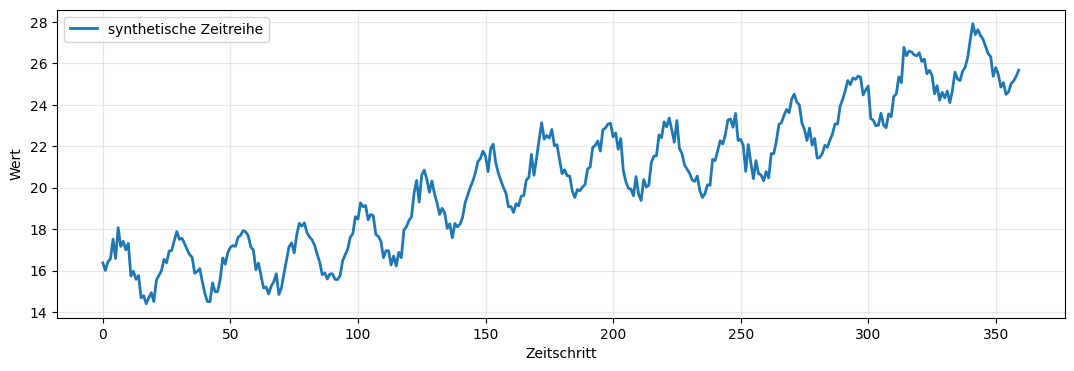

In [19]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df['time'], df['value'], linewidth=2, label='synthetische Zeitreihe')
ax.set_xlabel('Zeitschritt')
ax.set_ylabel('Wert')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


In [20]:
def make_supervised(series: np.ndarray, lookback: int = 24, horizon: int = 1):
    X, y = [], []
    for end in range(lookback, len(series) - horizon + 1):
        start = end - lookback
        X.append(series[start:end])
        y.append(series[end + horizon - 1])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.float32)

lookback = 24 * 7
X, y = make_supervised(df['value'].to_numpy(), lookback=lookback, horizon=1)
X.shape, y.shape



((192, 168), (192,))

In [21]:
n_samples = len(X)
train_end = int(n_samples * 0.7)
val_end = int(n_samples * 0.85)
X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

x_mean, x_std = X_train.mean(), X_train.std()
y_mean, y_std = y_train.mean(), y_train.std()
X_train_s = (X_train - x_mean) / x_std
X_val_s = (X_val - x_mean) / x_std
X_test_s = (X_test - x_mean) / x_std
y_train_s = (y_train - y_mean) / y_std
y_val_s = (y_val - y_mean) / y_std

train_ds = TensorDataset(torch.tensor(X_train_s), torch.tensor(y_train_s).unsqueeze(1))
val_ds = TensorDataset(torch.tensor(X_val_s), torch.tensor(y_val_s).unsqueeze(1))
test_tensor = torch.tensor(X_test_s)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)


In [22]:
class MLPForecaster(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32,1)
        )
    
    def forward(self, x):
        return self.net(x)
    
model = MLPForecaster(lookback).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # Adam ist das modernere Optimierungsverfahren
loss_fn = nn.MSELoss()

In [23]:
best_val = float('inf')
best_state = None 
patience = 5 
wait = 0
epochs = 50

for epoch in range(epochs):
    model.train()
    train_losses = []
    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = loss_fn(yb, y_pred)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    
    model.eval()
    val_losses = []
    with torch.no_grad():
        for xb,yb in val_loader:
            xb,yb = xb.to(device), yb.to(device)
            y_pred = model(xb)
            val_losses.append(loss_fn(y_pred,yb).item())
    
    mean_train = float(np.mean(train_losses))
    mean_val = float(np.mean(val_losses))

    if mean_val < best_val:
        best_val = mean_val
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()} # Gewichte einfrieren
        wait = 0 
    else:
        wait +=1
        if wait >= patience:
            break
    model.load_state_dict(best_state)


    


In [25]:
model.eval()
with torch.no_grad():
    mlp_pred_s = model(test_tensor.to(device)).squeeze(1).cpu().numpy()
mlp_pred = mlp_pred_s * y_std + y_mean
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
pd.DataFrame([
    
    {'model': 'pytorch_mlp', 'mae': mlp_mae, 'rmse': mlp_rmse},
]).round(4)


,model,mae,rmse
0,pytorch_mlp,0.7801,0.8583


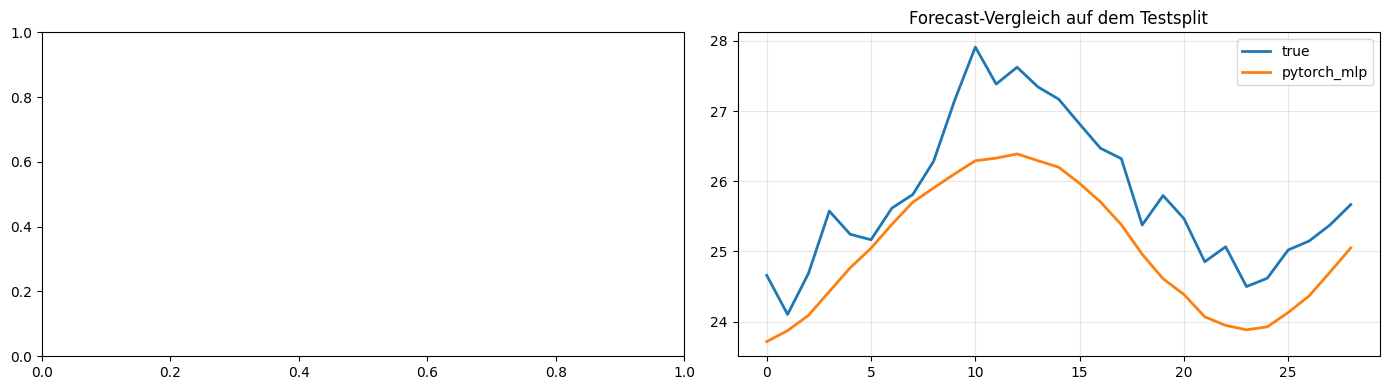

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sample = slice(0, 80)
axes[1].plot(y_test[sample], label='true', linewidth=2)
axes[1].plot(mlp_pred[sample], label='pytorch_mlp', linewidth=2)
axes[1].set_title('Forecast-Vergleich auf dem Testsplit')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


